# 2D Multi-Component Multi-Phase Lattice Boltzmann (LBM) Simulations 
__Author(s):__ Bernard Chang and Masa Prodanovic

__Last Update:__ Feb. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

In this hands-on activity, we will demonstrate the general algorithm used to perform multi-component multiphase (MCMP) lattice Boltzmann simulations. The goal of this exercise is to implement the fundamental components of the MCMP Shan-Chen model and to demonstrate how simulation parameters influence fluid behavior. This example is performed on a 2-dimensional lattice with 9 discrete velocities (D2Q9).

This notebook assumes basic understanding of lattice Boltzmann methods. For a more comprehensive review of basic concepts, please refer to the [5-2-1_lbm_d2q9_bgk](5_simulation/5-2-1_lbm_d2q9_bgk.ipynb) and [5-2-2_lbm_d2q9_scmp](5_simulation/5-2-2_lbm_d2q9_scmp.ipynb) notebooks.

Before we get started, let's import some packages


In [1]:
#@title Import Packages
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Tuple, Iterable, Optional

from functools import wraps

# Define a decorator to extend a class with new methods
def extend(cls, *, override=True):
    def decorator(func):
        if not override and hasattr(cls, func.__name__):
            raise AttributeError(
                f"{cls.__name__}.{func.__name__} already exists"
            )

        @wraps(func)
        def method(*args, **kwargs):
            return func(*args, **kwargs)

        setattr(cls, func.__name__, method)
        return method
    return decorator


## Setting up Multi-Component Multiphase (SCMP) Lattice Boltzmann Methods

### Background
As in single-phase and single-component multiphase lattice Boltzmann methods (LBM), the fundamental variable in **kinetic theory**, on which LBM is based, is the particle distribution function $f$. LBM models the mesoscopic dynamics of fluids by evolving $f$ according to the discretized Boltzmann equation. 

SCMP LBM extends this framework by introducing effective interparticle interactions that enable spontaneous phase separation into coexisting phases (liquid/vapor).

In MCMP LBM, each component has its own distribution function $f_i$. The component populations typically operate on the same lattice, but evolve (stream and collide) independently. It is further possible to assign different fluid properties (e.g., $\tau$, $\psi$) to each component. The components interact via interaction parameter, which results in Shan-Chen forces from neighboring densities and relaxation toward a common velocity.

To begin, we will define a class object called ```LBM_MCMP()``` where we will initialize several variables we need to start building our simulator, including the discrete velocity vectors and lattice weights.

***Note:*** that most parameters (e.g., $\tau$, $\psi_s$) are defined as an iterable with the same length as the number of components. The interaction strength matrix `G_mat` has shape `(n_comp, n_comp)` with zeros on the diagonal (self-interaction) and non-zero off-diagonal entries (component interactions). Field quantities (except for total velocity) are initialized to shapes `(n_comp, ...)`.

In [2]:
class LBM_MCMP:
    """
    Multi-Component Multi-Phase Lattice Boltzmann Method using Shan-Chen Model
    Components are indexed as alpha = 0, ..., (n_comp - 1)
    """
    def __init__(self, nx: int,
                 ny: int,
                 n_comp: int = 2,
                 tau: Iterable[float] = (1.0, 1.0),
                 cs2: float = 1.0 / 3.0,
                 G_mat: Iterable[Iterable] = [[0.0, 3.0], [3.0, 0.0]],
                 rho0: Iterable[float] = [1.0, 1.0],
                 G_ads: Iterable[float] = [0.0, 0.0],
                 psi_solid: Iterable[float] = [0.5, 0.5],
                 body_force: Optional[Iterable[float]] = [0.0, 0.0]) -> None:
        """
        Initialize MCMP
        Parameters:
        ---
        nx, ny : int
            Grid dimensions
        n_comp: int
            Number of components (fluids). Default = 2
        tau: Iterable[float]
            Per-component relaxation time. Must be of length (n_comp,). Default = [1.0, 1.0] (tau = 1.0 for all components)
        cs2: float
            Speed of sound squared. Default = 1/3 for D2Q9
        G_mat: np.ndarray
            Interaction strength matrix of shape (n_comp, n_comp). G_mat[alpha, beta] is the interaction strength between component alpha and beta.
            Must be symmetric with zeros on the diagonal.
            Default = 3.0 for all off-diagonal entries (strong phase separation) and 0 on the diagonal (no self-interaction)
        rho_0: Iterable[float]
            Per-component reference density for pseudopotential function. Default = (1.0, 1.0, ..., 1.0)
        G_ads: Iterable[float]
            Per-component fluid-solid interaction strength. Default = (-0.4, -0.4, ..., -0.4)
        psi_solid: float
            Solid pseudopotential function. Default = 0.5
        body_force: Iterable[float, float]
            Force components in x and y directions. Default = (0.0, 0.0)
        """
        self.nx = nx
        self.ny = ny

        self.n_comp = n_comp
        self.tau = np.asarray(tau, dtype=np.float64)
        self.omega = 1.0 / self.tau
        assert len(self.omega) == n_comp, f"omega must be of length {n_comp}, got {len(self.omega)}"

        self.cs2 = cs2

        self.G_mat = np.asarray(G_mat, dtype=np.float64)
        assert self.G_mat.shape == (n_comp, n_comp), f"G_mat must be of shape ({n_comp}, {n_comp}), got {self.G_mat.shape}"

        self.G_ads = np.asarray(G_ads, dtype=np.float64)
        assert len(self.G_ads) == n_comp, f"G_ads must be of length {n_comp}, got {len(self.G_ads)}"


        self.c = np.array([
            [0, 0],
            [1, 0], [0, 1], [-1, 0], [0, -1],
            [1, 1], [-1, 1], [-1, -1], [1, -1]], dtype=np.int16)
        self.weights = np.array(
            [4. / 9.,
             1. / 9., 1. / 9., 1. / 9., 1. / 9.,
             1. / 36., 1. / 36., 1. / 36., 1. / 36.], dtype=np.float64)

        self.opposite = np.array(
            [0,
             3, 4, 1, 2,
             7, 8, 5, 6], dtype=np.uint8)

        # Fields
        self.rho = np.ones((n_comp, nx, ny), dtype=np.float64)

        self.rho_0 = np.asarray(rho0, dtype=np.float64)
        self.u = np.zeros((2, nx, ny), dtype=np.float64)
        self.f = np.zeros((n_comp, 9, nx, ny), dtype=np.float64)
        self.f_eq = np.zeros((n_comp, 9, nx, ny), dtype=np.float64)
        self.psi = np.empty((n_comp, nx, ny), dtype=np.float64)
        self.psi_s = np.asarray(psi_solid, dtype=np.float64)

        self.timestep = 0
        self.solid_mask = np.zeros((nx, ny), dtype=bool)
        self.rho_min_threshold = 1.e-6  # Minimum density threshold
        self.body_force = np.asarray(body_force, dtype=np.float64) # Force components

    def initialize_density_field(self, rho_init: np.ndarray, u_init: Optional[np.ndarray] = None) -> None:
        """
        Initialize simulation from arbitrary density field
        Parameters:
        ---
        rho_init: ndarray (nx, ny)
            Initial density field
        u_init: ndarray (2, nx, ny), optional
            Initial velocity field. Defaults to zero everywhere
        Returns:
        ---
        None
        """
        if rho_init.shape != (self.n_comp, self.nx, self.ny):
            raise ValueError(f"rho_init has shape {rho_init.shape}, which does not match grid shape ({self.n_comp}, {self.nx}, {self.ny})")
        self.rho = rho_init.copy().astype(np.float64)

        self.u = u_init.copy().astype(np.float64) if u_init is not None else np.zeros((2, self.nx, self.ny), dtype=np.float64)
        assert self.u.shape == (2, self.nx, self.ny), f"u_init has shape {u_init.shape}, which does not match expected (2, {self.nx}, {self.ny})"

        # Initialize equilibrium distribution
        self.psi = self.compute_pseudopotential(self.rho)
        self.f_eq = self.compute_equilibrium(self.rho, self.u)
        self.f = self.f_eq.copy()

    def set_solids_from_mask(self, solid_mask: np.ndarray) -> None:
        """
        Set solid nodes from a boolean mask
        Parameters:
        ---
        solid_mask: ndarray (nx, ny)
            Boolean array where True indicates solid nodes
        Returns:
        ---
        None
        """
        if solid_mask.shape != (self.nx, self.ny):
            raise ValueError(f"solid_mask has shape {solid_mask.shape}, which does not match grid shape ({self.nx}, {self.ny})")
        self.solid_mask = solid_mask.copy()
        # self.f_eq[:, self.solid_mask] = 0
        self.f[:, :, self.solid_mask] = 0
        self.u[:, self.solid_mask] = 0

### Obtaining Macroscopic Properties

Component-wise macroscopic properties, such as mass and momentum density, can still be can be obtained from the weighted sum (moments) of the *discrete-velocity distribution function, $f_i(x, t)$*

The mass density is given by the zeroth moment:
$$\rho^{(\sigma)} = \sum f_i^{(\sigma)},$$
and the momentum density by the first moment:
$$\rho^{(\sigma)} u^{(\sigma)} = \sum c_i f_i^{(\sigma)},$$

where $c_i$ are the discrete lattice velocities defined by the chosen lattice.

These relations are identical to those used in single-phase BGK.

In [3]:
@extend(LBM_MCMP)
def compute_macroscopic(self, f: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute macroscopic density and velocity from distribution function
    Parameters:
    ---
    f: ndarray (9, nx, ny)
        Distribution function
    Returns:
    ---
    rho: ndarray (nx, ny)
        Density field
    u: ndarray (2, nx, ny)
        Velocity field
    """
    rho = np.sum(f, axis=1)  # Sum over distribution directions
    rho = np.clip(rho, self.rho_min_threshold, None)

    # Compute per-component momentum
    u = np.zeros((self.n_comp, 2, self.nx, self.ny), dtype=np.float64)

    for i in range(9):
        u[:, 0] += f[:, i] * self.c[i, 0]  # (n_comp, nx, ny)
        u[:, 1] += f[:, i] * self.c[i, 1]  # (n_comp, nx, ny)

    # Normalize per-component momentum by per-component density
    u[:, 0] /= np.maximum(rho, 1e-12)
    u[:, 1] /= np.maximum(rho, 1e-12)

    # Zero velocity in solids
    u[:, :, self.solid_mask] = 0.0

    return rho, u

### Equilibrium Calculation

The most important change to the MCMP model over SCMP is the treatment of the macroscopic velocity used in the equilibrium distribution function. The equilibrium distribution function itself retains the standard isothermal form from the BGK model. 

After collisions, the distribution of each component $f_i^{(\sigma)}$ relaxes toward the equilibrium distribution, $f_i^{eq, (\sigma)}$ as:

$$ f_i^{eq, (\sigma)}(x, t) = w_i \rho^{\sigma} \left(1 + \frac{u \cdot c_i}{c_s^2} + \frac{(u \cdot c_i)^2}{2c_s^4} - \frac{u \cdot u}{2c_s^2} \right).$$

Assuming the isothermal lattice Boltzmann equation ($p = c_s^2 \rho$) and operating in lattice units ($\Delta x = \Delta t = 1$), the equilibrium distribution function can be simplified to

$$ f_i^{eq}(x, t) = w_i \rho \left(1 + 3(u \cdot c_i) + \frac{9}{2}(u \cdot c_i)^2 - \frac{3}{2} (u \cdot u) \right).$$

**Note:** As in SCMP, non-ideal effects do not enter through the equilibrium distribution. The equilibrium remains the same as the standard BGK model. All non-ideal interactions are introduced through the Shan-Chen interaction forces and their incorporation into the velocity used in $f_i^{eq, (\sigma)}$.



In [4]:
@extend(LBM_MCMP)
def compute_equilibrium(self, rho: np.ndarray, u: np.ndarray) -> np.ndarray:
    """
    Compute equilibrium distribution function
    Parameters:
    ---
    rho: ndarray (nx, ny)
        Density field
    u: ndarray (2, nx, ny)
        Velocity field
    Returns:
    ---
    f_eq: ndarray (9, nx, ny)
        Equilibrium distribution
    """
    f_eq = np.zeros_like(self.f)
    u_sq = u[0]**2 + u[1]**2
    for i in range(9):
        u_dot_c = self.c[i, 0] * u[0] + self.c[i, 1] * u[1]
        base = self.weights[i] * (1.0 + u_dot_c / self.cs2 + (u_dot_c**2) / (2.0 * self.cs2**2) - u_sq / (2.0 * self.cs2))
        # Broadcast base (nx,ny) over components
        f_eq[:, i] = rho * base
    f_eq[:, :, self.solid_mask] = 0.0

    return f_eq

### Barycentric Velocity

The velocity taken in the equilibrium distribution function should be a suitably defined common velocity field (not component-wise velocity). 

In the original Shan-Chen formulation, this was taken as $u = u' + \tau^{(\sigma)} F_{SC}^{(\sigma)}$, where $u' = \frac{\sum_\sigma\frac{\rho^{(\sigma)}u^{(\sigma)}}{\tau^{(\sigma)}}}{\sum_\sigma\frac{\rho^{(\sigma)}}{\tau^{(\sigma)}}}$.

However, this formulation introduces an unphysical interfacial tension dependence on the relaxation time. To avoid this, we can use Guo forcing, which requires us to compute the barycentric velocity:

$$ u_b = \frac{1}{\rho_{\text{tot}}} \sum_\sigma \left(\sum_i f_i^{(\sigma)}c_i + \frac{F_{sc}^{(\sigma)}\Delta t}{2}\right)$$

Note that this is essentially the same as the half-force correction we did for the BGK and SCMP models!

In [5]:
@extend(LBM_MCMP)
def compute_barycentric_velocity(self, F) -> np.ndarray:
    """
    Compute barycentric velocity from force contributions
    Parameters:
    ---
    F : ndarray (2, nx, ny)
        Force [Fx, Fy]
    Returns:
    ---
    u_b : ndarray (2, nx, ny)
        Barycentric velocity [u_b_x, u_b_y]
    """
    if F.ndim == 4 and F.shape[0] == self.n_comp:
        F_tot = np.sum(F, axis=0)  # (2, nx, ny)
    elif F.ndim == 3 and F.shape[0] == 2:
        F_tot = F
    else:
        raise ValueError(f"F shape {F.shape} must be (n_comp,2,nx,ny) or (2,nx,ny).")

    rho_tot = np.sum(self.rho, axis=0)
    j_tot = np.zeros((2, self.nx, self.ny), dtype=np.float64)
    for i in range(9):
        j_tot[0] += np.sum(self.f[:, i] * self.c[i, 0], axis=0)  # sum over components
        j_tot[1] += np.sum(self.f[:, i] * self.c[i, 1], axis=0)
    # Half-force correction and division by total density
    u_b = (j_tot + 0.5 * F_tot) / np.maximum(rho_tot, self.rho_min_threshold)
    u_b[:, self.solid_mask] = 0.0
    return u_b

### Collision Step

Recall that LBM advances in two main steps: **collision** and **streaming**. In the standard Shan-Chen MCMP model, the collision operator for each component retains the standard BGK form in lattice units: 

$$\Omega_i^{(\sigma)}(x, t) = -\frac{f_i^{(\sigma)}(x, t) - f_i^{eq,(\sigma)}(x, t)}{\tau^{(\sigma)}}.$$

The post-collision distribution functions are therefore:

$$\tilde{f}_i^{(\sigma)}(x, t) = f_i^{(\sigma)}(x, t) + \Omega_i^{(\sigma)}(x, t) = f_i^{(\sigma)}(x, t) - \frac{1}{\tau^{(\sigma)}}\left[f_i^{(\sigma)}(x, t) - f_i^{eq, (\sigma)}(x, t)\right].$$

This operator describes how the distributions of each component $f_i^{(\sigma)}$ relax toward equilibrium $f_i^{eq, (\sigma)}$ at a rate determined by the component-wise relaxation time $\tau^{(\sigma)}$. For reference, the kinematic viscosity of the fluid is related to the relaxation time as $\nu^{(\sigma)} = c_s^2 (\tau^{(\sigma)} - \frac{1}{2})$.

**Note:** As in SCMP, we use BGK here for simplicity. MCMP variants may employ multiple relaxation time (MRT), two relaxation time (TRT), or other collision models.



In [6]:
@extend(LBM_MCMP)
def collide(self) -> np.ndarray:
    """
    Perform collision step

    Returns:
    ---
    f_post: ndarray (9, nx, ny)
        Post-collision distribution function
    """
    f_post = self.f - self.omega[:, None, None, None] * (self.f - self.f_eq)
    return f_post

### Streaming & Bounceback

In MCMP Shan-Chen, the streaming step is applied to each component separately, but the operation itself is unchanged from the BGK/SCMP setup. For each component, the post-collision populations are streamed along their discrete velocities $c_i$ to neighboring nodes

$$f_i^{(\sigma)}(x + c_i, t) = f_i^{(\sigma)}(x, t).$$

Note that this step is identical in form to the BGK model. The only update is to perform it for all components.

Periodic boundaries can still be handled by the ```numpy.roll()``` function in Python. 

#### Bounceback Boundary Condition

For solid walls, we impose no-slip at solid boundary nodes using bounceback. 

The idea remains that populations that would stream into a solid node are reflected back in the opposite direction. In MCMP, bounceback is again applied independently to each component.

<img src='https://www.researchgate.net/profile/Robert-Bialik/publication/258843003/figure/fig1/AS:392599690072074@1470614468708/No-slip-boundary-condition-bounce-back-boundary-condition-for-the-collision-with-the.png' height='300'>

In [7]:
@extend(LBM_MCMP)
def stream_and_bounceback(self, f_post: np.ndarray) -> np.ndarray:
    # f_post: post-collision distributions (9, nx, ny)
    f_next = np.zeros_like(f_post)
    solid = self.solid_mask
    fluid = ~solid

    for a in range(self.n_comp):
        for i in range(9):
            src = np.roll(np.roll(f_post[a, i], self.c[i, 0], axis=0), self.c[i, 1], axis=1)

            # Indicator function for upstream solid
            upstream_solid = np.roll(np.roll(solid, self.c[i, 0], axis=0), self.c[i, 1], axis=1)

            # For fluid cells:
            # - If upstream is fluid, take src (normal streaming)
            # - If upstream is solid, apply bounce-back: reflect local opposite
            normal_mask = fluid & (~upstream_solid)
            bounce_mask = fluid & upstream_solid

            f_next[a, i][normal_mask] = src[normal_mask]
            f_next[a, i][bounce_mask] = f_post[a, self.opposite[i]][bounce_mask]

        # Zero out solids for posterity
        f_next[a, :, self.solid_mask] = 0  # Zero out solid cells
    return f_next

### Forcing
#### Pseudopotential, $\psi^{(\sigma)}(\rho)$, and Inter-Component Interactions

In MCMP, non-ideal behavior and phase segregation are, again, represented through pseudopotentials. Each component carries its own pseudopotential field and components interact with each other through these fields. 

The main difference here is that for immiscible fluids, we have multiple components that repel each other via the pair-wise intercomponent interaction parameter. This mechanism generates diffuse interfaces, controls miscibility, and drives phase separation without explicit interface tracking.

For each component, we define a pseudopotential, $\psi^{(\sigma)}(\rho)$. The pseudopotential field is a smooth function of density. While it is possible to use different pseudopotential functions for different components, most simple MCMP implementations assume the same functional form for all components. As with the SCMP model, we take

$$\psi^{(\sigma)}(\rho^{(\sigma)}) = \rho^{(\sigma)}_0 (1 - \exp{(-\rho^{(\sigma)} / \rho^{(\sigma)}_0)}),$$

where $\rho^{(\sigma)}_0$ is commonly taken to be 1.

With pseudopotential interactions, the effective equation of state is:

$$ p = c_s^2 \sum_\sigma\rho^{(\sigma)} + \frac{c_s^2\Delta t^2}{2}\sum_{\sigma,\tilde{\sigma}}G_{\sigma\tilde{\sigma}}\psi^{(\sigma)}\psi^{(\tilde{\sigma})}.$$

where the first term represents the ideal gas properties of the components and the second term accounts for non-ideal effects that can lead to phase separation.

As in SCMP, interfaces in MCMP are diffuse, meaning that component densities vary smoothly across several lattice nodes. Near interfaces, neighboring lattice sites see different compositions and, therefore, unequal pseudopotentials. These anisotropic interaction forces generate an effective interfacial tension between the components. The magnitude of this effective interfacial tension depends on the choice of $G_{\sigma\tilde{\sigma}}$ and the chosen pseudopotential function.

##### Numerical Considerations

Despite its simplicity and robustness, the Shan–Chen pseudopotential model has well-known numerical limitations.

A common issue is the presence of spurious currents, which appear as small, nonphysical velocity fields near interfaces, especially around curved surfaces. These currents are influenced by lattice discretization errors and tend to grow with increasing interaction strength $|G_{\sigma\tilde{\sigma}}|$, surface tension, and density ratio. $|G_{\sigma\tilde{\sigma}}|$ also affects the interfacial thickness, where larger $|G_{\sigma\tilde{\sigma}}|$ leads to sharper interfaces but exacerbates spurious currents and can ultimately lead to unstable behavior.

Additionally, the standard single-component model typically supports moderate density ratios. Other LBM formulations have been designed to address some of these limitations.


In [8]:
@extend(LBM_MCMP)
def compute_pseudopotential(self, rho: np.ndarray) -> None:
    """
    Compute pseudopotential function psi(rho)
    Parameters:
    ---
    rho: ndarray (nx, ny)
        Density field
    Returns:
    ---
    psi: ndarray (nx, ny)
        Pseudopotential field
    """
    psi = np.zeros_like(rho)
    for a in range(self.n_comp):
        psi[a] = self.rho_0[a] * (1 - np.exp(-rho[a] / self.rho_0[a]))
    psi[:, self.solid_mask] = 0.0
    return psi

#### Shan-Chen Forcing

##### Fluid-Fluid Interaction
In the pseudopotential framework, non-ideal fluid behavior is introduced through pairwise interaction forces between the different fluid components. As discussed above, this pseudopotential is responsible for phase separation and interfacial tension, and is incorporated into the LBM simulation through a forcing scheme.

For a multi-component fluid, the Shan-Chen fluid-fluid interaction force acting on component $\sigma$ is given by:

$$ F^{(\sigma)}_{ff} = -\psi^{(\sigma)}(x) \sum_{\tilde{\sigma} \neq \sigma} G_{\sigma\tilde{\sigma}}\sum_i w_i \psi^{(\tilde{\sigma})}(x + c_i) c_i, $$

where $G_{\sigma\tilde{\sigma}}$ is the interaction strength between components $\sigma$ and $\tilde{\sigma}$, $\psi^{(\sigma)}$ is the pseudopotential, and $c_i$ and $w_i$ are the lattice velocity directions and weights. 

The intuition here is that in homogeneous regions, the force contributions cancel by symmetry. In contrast, near density gradients (e.g., at interfacial regions), the force becomes unbalanced. If $G_{\sigma\tilde{\sigma}} > 0$, the components will repel each other, promoting phase separation.

##### Fluid-Solid Interaction and Wetting
The same interaction concept can be extended to model fluid-solid interactions, enabling the simulation of wetting effects without explicitly imposing boundary conditions on the solid surfaces. 

There are a few ways to implement this. Here, we treat solid nodes using an indicator function $S(x)$, which takes the value 1 if a node is solid and 0 otherwise. The fluid-solid interaction force can be independently computed and can be added to the fluid-fluid interaction force as:

$$ F^{(\sigma)}_{fs} = -G_{\sigma, ads} \psi^{(\sigma)}(x) \sum_i w_i \psi_s S(x+c_i) c_i, $$

where $G_{\sigma, ads}$ is the adhesive interaction strength, and $\psi_s(x)$ is a constant pseudopotential prescribed to the solid phase. By tuning $G_{\sigma, ads}$ and $\psi_s$, the solid wall can be made effectively attracting (wetting) or repulsive (non-wetting). ​

***Note:*** While not strictly necessary, we typically set $G_{\tilde{\sigma}, ads} = -G_{\sigma, ads}$ for binary fluid systems.

In [9]:
@extend(LBM_MCMP)
def compute_shan_chen_force(self, psi: np.ndarray) -> np.ndarray:
    """
    Compute Shan-Chen intermolecular force. This force drives phase separation when G < 0.
    Returns:
    ---
    F : ndarray (2, nx, ny)
        Force field [Fx, Fy]
    """
    F = np.zeros((self.n_comp, 2, self.nx, self.ny), dtype=np.float64)

    for i in range(1, 9):  # skip rest direction
        ex, ey = int(self.c[i, 0]), int(self.c[i, 1])

        w_i = self.weights[i]
        solid_nb = np.roll(np.roll(self.solid_mask, -ex, axis=0), -ey, axis=1)
        fluid_nb = ~solid_nb

        # For each component alpha
        for a in range(self.n_comp):
            psi_a = psi[a]
            # Fluid-fluid interactions per component
            for b in range(self.n_comp):
                G_ab = self.G_mat
                psi_b_nb = np.roll(np.roll(psi[b], -ex, axis=0), -ey, axis=1)
                F[a, 0] += -G_ab[a, b] * w_i * ex * psi_a * (psi_b_nb * fluid_nb)
                F[a, 1] += -G_ab[a, b] * w_i * ey * psi_a * (psi_b_nb * fluid_nb)

            # Fluid-solid interactions per component
            if self.G_ads[a] != 0.0:
                F[a, 0] += -self.G_ads[a] * w_i * ex * psi_a * (self.psi_s[a] * solid_nb)
                F[a, 1] += -self.G_ads[a] * w_i * ey * psi_a * (self.psi_s[a] * solid_nb)

    # Zero inside solids
    F[:, :, self.solid_mask] = 0.0
    return F

#### Body Forces

In addition to the Shan-Chen interaction forces, lattice Boltzmann simulations often include external body forces, such as gravity or pressure-driven acceleration. In MCMP, these forces can be applied component-wise or to the mixture as a whole, depending on the physical model.

For a prescribed body acceleration $b = [b_x, b_y]$, the physical force on a given component is proportional to its mass density as,

$$ F_{\text{ext}}^{(\sigma)}(x) = \rho^{(\sigma)}(x)b.$$

This can be added to other forces acting on that component (e.g., fluid-fluid and fluid-solid Shan-Chen forces):

$$ F_{\text{tot}}^{(\sigma)}(x) = F_{ff}^{(\sigma)}(x) + F_{fs}^{(\sigma)}(x) + F_{\text{ext}}^{(\sigma)}(x). $$

The total force acting on the mixture is simply the sum of the forces acting on each component:

$$ F_{\text{tot}} = \sum_{\sigma} F_{\text{tot}}^{(\sigma)}(x) = \left(\sum_{\sigma} \rho^{(\sigma)}(x)\right)b$$

Solid nodes are typically excluded, so no body force is applied inside solid regions.

In [10]:
@extend(LBM_MCMP)
def compute_body_force(self) -> np.ndarray:
    """
    Compute component-wise body force
    Parameters:
    ---
    Returns:
    ---
    F : ndarray (n_comp, 2, nx, ny)
    """
    F_body = np.zeros((self.n_comp, 2, self.nx, self.ny), dtype=np.float64)
    for a in range(self.n_comp):
        F_body[a] = self.rho[a] * self.body_force[:, None, None]

    F_body[:, :, self.solid_mask] = 0.0

    return F_body

#### Guo Forcing

In the MCMP Shan–Chen model, each component experiences its own total force, and all forces act through a common mixture velocity in the equilibrium and forcing terms.

At each lattice node, the total force on each component is given as the sum of all contributions, e.g.:

$$ F^{(\sigma)}_{\text{tot}} = F^{(\sigma)}_{ff} + F^{(\sigma)}_{fs} + F^{(\sigma)}_{\text{ext}}. $$

The component-wise total force can be incorporated into the collision step using Guo's forcing scheme. The forcing contribution to a component's distribution function along the lattice direction $c_i$ is:

$$ F^{(\sigma)}_i = \left(1 - \frac{1}{2\tau^{(\sigma)}}\right)w_i \left[\frac{c_i - u}{c_s^2} + \frac{(c_i \cdot u)c_i}{c_s^4}\right] F^{(\sigma)}_{total}. $$

**IMPORTANT:** The macroscopic velocity, $u$, is defined as using the barycentric velocity,

$$ u = \frac{1}{\rho_{\text{tot}}} \sum_\sigma \left(\sum_i f_i^{(\sigma)}c_i + \frac{F_{sc}^{(\sigma)}\Delta t}{2}\right)$$

The first term is the usual velocity moment from the particle distributions. The second term accounts for the momentum that will be added by the force during the time step. Here, we perform the half-force velocity correction during the time step function, not in the following Guo forcing computation function.

The Guo forcing term for each lattice direction is then added to the collision step:

$$ f^{(\sigma)}_i(x, t + \Delta t) = f^{(\sigma)}_i(x, t) + \frac{1}{\tau^{(\sigma)}} \left[f^{(\sigma)}_i(x, t) - f_i^{eq, (\sigma)}(\rho^{(\sigma)}, u)\right] + F^{(\sigma)}_i. $$

In [11]:
@extend(LBM_MCMP)
def compute_guo_forcing(self, F, u) -> np.ndarray:
    """
    Compute Guo forcing
    Parameters:
    ---
    F : ndarray (2, nx, ny)
        Shan-Chen force + Body force
    Returns:
    ---
    guo_force : ndarray (2, nx, ny)
        Guo forcing term
    """
    guo_force = np.zeros_like(self.f, dtype=np.float64)
    ci = self.c[:, :, None, None]
    ui = u[None, :, :, :]
    ci_dot_u = np.sum(ci * ui, axis=1)
    term2 = (ci - ui) / self.cs2 + (ci_dot_u[:, None, :, :] * ci) / (self.cs2 ** 2)

    for a in range(self.n_comp):
        Fi = F[a][None, :, :, :]
        Si = np.sum(term2 * Fi, axis=1)
        guo_force[a] = self.weights[:, None, None] * (1 - 0.5 * self.omega[a]) * Si

    guo_force[:, :, self.solid_mask] = 0.0
    return guo_force

### Phase Field (for visualization)

Because there is no single scalar "order parameter" built into the MCMP Shan-Chen model, it is convenient to construct derived scalar fields to show where each component is located and how the interfaces evolve. 

There are several common choices. In this notebook, we visualize the phase field using the normalized composition (assuming 2 components):

$$ \phi = \frac{\rho^{(A)} - \rho^{(B)}}{\rho^{(A)} + \rho^{(B)} + \epsilon}.$$

Here, $\phi \approx 1$ corresponds to areas where component A is dominant, $\phi \approx -1$ corresponds to areas where component B is dominant, and $\phi \approx 0$ corresponds to the interface.

In [12]:
@extend(LBM_MCMP)
def compute_phase_field(self) -> np.ndarray:
    """
    Compute phase field (e.g., for visualization)
    Parameters:
    ---
    Returns:
    ---
    phi : ndarray (nx, ny)
        Phase field (e.g., normalized density or pseudopotential)
    """
    # Example: normalized density difference between first two components
    phi = (self.rho[0] - self.rho[1]) / np.maximum(self.rho[0] + self.rho[1], 1e-12)

    return phi

### Putting it all together

We now have the necessary functions to run MCMP simulations! In the following cell, we will define a class method to complete one LBM time step. The general workflow for each iteration is mostly the same as before:

1. Compute macroscopic variables (density and velocity) for all components
2. Compute the pseudopotential for all components
3. Compute all force contributions for each component (Shan-Chen fluid-fluid, Shan-Chen solid-fluid, and body forces)
4. Compute barycentric velocity correction
5. Compute equilibrium distributions for each component with barycentric velocity correction
6. Compute Guo forcing and apply collision for each component
7. Apply streaming and bounce-back for each component

In [13]:
@extend(LBM_MCMP)
def step(self, body_force_override: Iterable[float] = None):
    """
    Perform one simulation step
    Parameters:
    ---
    body_force_override: Iterable[float], optional
        If provided, use this body force instead of the one provided in the constructor. Should be a 2-element iterable for (Fx, Fy).

    Returns:
    ---
    None
    """
    # Macroscopic variables
    self.rho, self.u_comp = self.compute_macroscopic(self.f)

    # Compute pseudopotential
    self.psi = self.compute_pseudopotential(self.rho)

    # Compute Inter-species force
    F = self.compute_shan_chen_force(self.psi)

    # Apply body force, if specified
    if body_force_override is not None:
        self.body_force = body_force_override

    F += self.compute_body_force()

    #  Compute Barycentric velocity
    self.u = self.compute_barycentric_velocity(F)

    # Compute equilibrium distribution
    self.f_eq = self.compute_equilibrium(self.rho, self.u)
    
    # Guo Forcing
    guo_force = self.compute_guo_forcing(F, self.u)
    
    # Collide
    f_post = self.collide() + guo_force

    # Stream and Bounceback
    self.f = self.stream_and_bounceback(f_post)

    self.timestep += 1

## Validation Case 1: Flat Interface

In the first validation case, we consider a planar interface for the Shan-Chen MCMP LBM model. This test provides a fundamental assessment of interfacial equilibrium and force balance in a two-component system.

In this example, we initialize two fluid components each occupying half of the domain. The initial interface between the two components is sharp, and the velocity field is set to zero throughout the domain. Because the density profile is not in mechanical equilibrium, the system evolves under the intercomponent interaction force. As the simulation progresses, the initial sharp interface relaxes into a diffuse transition region.

As we'll observe, the intercomponent interaction strength parameter ($G_{AB}$) increases, the repulsive force between the components grows, resulting in sharper density contrasts and thinner interfaces (higher surface tension). However, when $G_{AB}$ becomes too large, the simulation introduces spurious currents and risks instability.

In [ ]:
def flat_interface(G: float=3.0):
    """
    Runs flat interface test at specified G
    Parameters:
    ---
    G: float
    Interaction strength parameter G
    
    Returns:
    ---
    lbm: LBM_MCMP
        Final simulation object after running phase separation
    """

    nx, ny = 100, 100
    lbm = LBM_MCMP(
        nx=nx, ny=ny, 
        n_comp=2,
        tau=[1.0, 1.0],
        cs2=1.0/3.0,
        G_mat=np.array([[0.0, G],
                        [G, 0.0]], dtype=np.float64),  # moderate demixing
        rho0=[1.0, 1.0],
        G_ads=[0.0, 0.0],      # no walls
        psi_solid=[0.0, 0.0],
        body_force=[0.0, 0.0]
    )

    # Initial densities
    rho = np.zeros((2, nx, ny), dtype=np.float64)
    rho[0, :nx//2, :] = 1.0
    rho[1, :nx//2, :] = 1e-3
    rho[0, nx//2:, :] = 1e-3
    rho[1, nx//2:, :] = 0.8
    
    lbm.initialize_density_field(rho_init=rho)

    # --- Run for 1000 steps ---
    total_steps = 1000

    for _ in tqdm(range(total_steps + 1)):
        lbm.step()

    return lbm

100%|██████████| 1001/1001 [00:19<00:00, 50.30it/s]


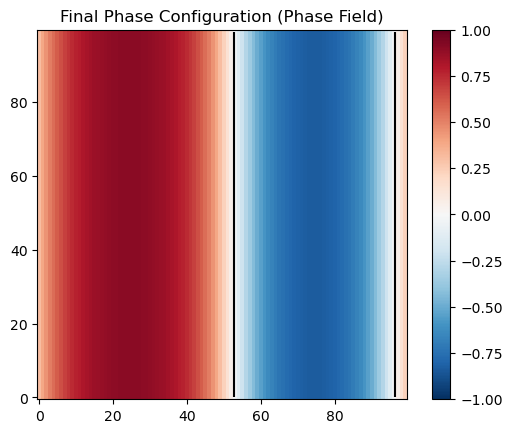

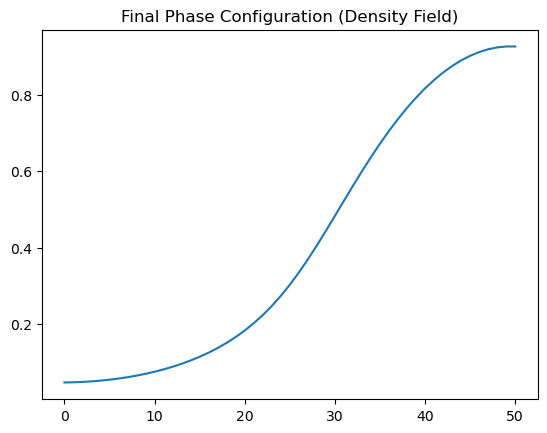

In [ ]:
flat_interface_sim = flat_interface(G=3)

# Plot final phase configuration
phase_field = flat_interface_sim.compute_phase_field()
plt.figure()
plt.imshow(phase_field.T, origin='lower', cmap='RdBu_r', vmin=-1.0, vmax=1.0)
plt.colorbar()
plt.contour(phase_field.T, levels=[0.0], colors='k')
plt.title('Final Phase Configuration (Phase Field)')

# Plot line profile across the interface
plt.figure()
plt.plot(flat_interface_sim.rho[1, 25:76, 50])
plt.title('Final Phase Configuration (Density Field)')
plt.show()


## Demonstration Case 2: Droplet Coalescence

In the second demonstration case, we consider droplet coalescence to observe surface tension effects and momentum exchange during topological changes of the interface.

In this example, we initialize two droplets of component A within a continuous background of component B. The droplets are placed in close proximity (but not initially touching). We provide a small velocity to the droplets to move them toward each other.

As the simulation progresses, the droplets merge together and relax toward a circular equilibrium shape that minimizes the total interfacial area (and, therefore, surface energy).





In [75]:
def droplet_coalescence(G: float=6.0, total_steps: int = 4_000, snapshot_every: int = 1000):
    """Run droplet coalescence simulation and capture snapshots at specified time steps
    Parameters:
    ---
    G: float
        Interaction strength parameter G
        
    Returns:
    ---
    lbm: LBM_SCMP
        Final simulation object after running phase separation
    """

    nx, ny = 150, 150
    lbm = LBM_MCMP(
        nx=nx, ny=ny, n_comp=2,
        tau=[1.0, 1.0],
        cs2=1.0/3.0,
        G_mat=np.array([[0.0, G],
                        [G, 0.0]], dtype=np.float64),  # moderate demixing
        rho0=[1.0, 1.0],
        G_ads=[0.0, 0.0],      # no walls
        psi_solid=[0.0, 0.0],
        body_force=[0.0, 0.0]
    )

    # --- Two droplets (all arrays in shape (nx, ny)) ---
    R = 24
    sep = 2.5 * R
    x1, y1 = nx//2 - sep//2, ny//2
    x2, y2 = nx//2 + sep//2, ny//2

    # Circle masks via broadcasting (avoid meshgrid transposes)
    x = np.arange(nx)[:, None]    # (nx, 1)
    y = np.arange(ny)[None, :]    # (1, ny)
    mask1 = ((x - x1)**2 + (y - y1)**2) <= R**2
    mask2 = ((x - x2)**2 + (y - y2)**2) <= R**2
    maskA = mask1 | mask2

    # Densities
    rho = np.zeros((2, nx, ny), dtype=np.float64)
    rho[0][maskA] = 1.0
    rho[1][maskA] = 1e-3
    rho[0][~maskA] = 1e-3
    rho[1][~maskA] = 1.0

    # Initial velocities (simple: uniform inside droplets)
    u_0 = 0.02
    u_init = np.zeros((2, nx, ny), dtype=np.float64)
    u_init[0][mask1] = u_0
    u_init[0][mask2] = -u_0

    lbm.initialize_density_field(rho_init=rho, u_init=u_init)

    # --- Run and plot every 1000 steps ---
    for step in tqdm(range(total_steps + 1)):
        lbm.step()
        if step % snapshot_every == 0:
            # Phase field (transpose only for plotting)
            phiT = lbm.compute_phase_field().T
            plt.figure(figsize=(9, 4))
            plt.imshow(phiT, origin="lower", extent=[0, nx, 0, ny],
                    cmap="RdBu_r", vmin=-1.0, vmax=1.0, interpolation="nearest")
            plt.colorbar(label="$\phi$")
            plt.contour(phiT, levels=[0.0], colors='k')
            plt.title(f"Two-droplet collision | t={lbm.timestep}")
            plt.xlabel("x"); plt.ylabel("y")
            
            plt.tight_layout()
    plt.show()
    
    return lbm

  0%|          | 0/5001 [00:00<?, ?it/s]

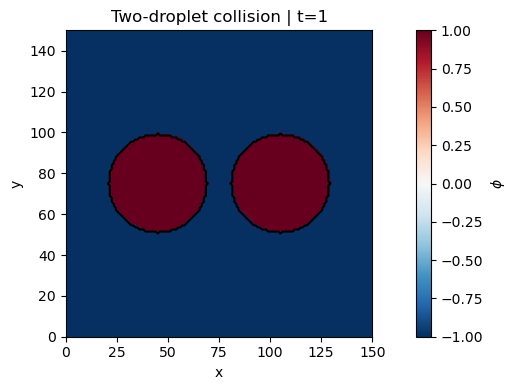

 20%|█▉        | 998/5001 [00:45<02:47, 23.84it/s]

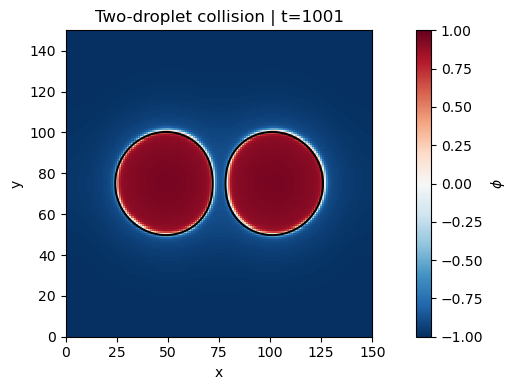

 40%|███▉      | 1998/5001 [01:32<02:10, 23.05it/s]

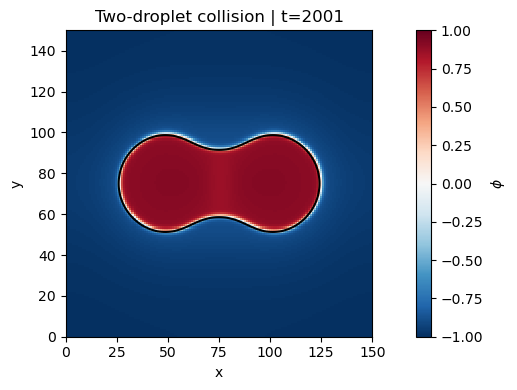

 60%|█████▉    | 2998/5001 [02:17<01:29, 22.47it/s]

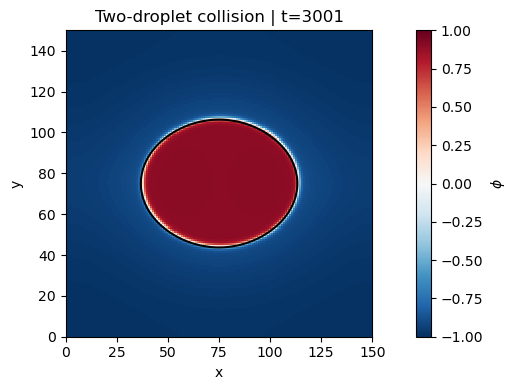

 80%|███████▉  | 3999/5001 [03:05<00:46, 21.72it/s]

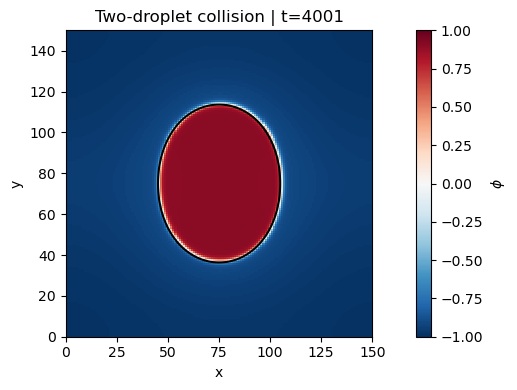

100%|█████████▉| 4998/5001 [03:51<00:00, 23.59it/s]

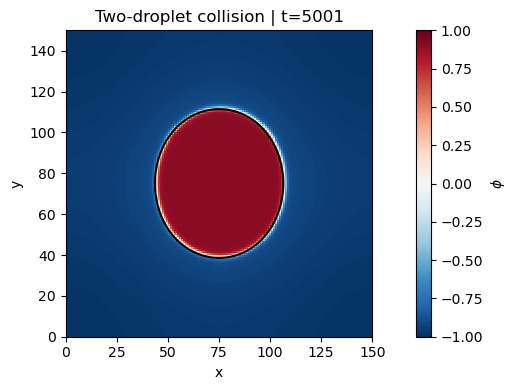

100%|██████████| 5001/5001 [03:52<00:00, 21.52it/s]


In [ ]:
droplet_coalescence()

## Validation Case 3: Contact Angle

In this validation case, we simulate the contact angle between a fluid droplet and a solid interface. The resulting contact angle reflects the balance between fluid-fluid and fluid-solid interaction forces.

The simulation consists of a single fluid droplet placed on a flat solid surface. As a reminder, we model the solid-fluid interaction via a pseudopotential wall force that is parameterized by $G_{ads}$. By varying $G_{ads}$, we observe how the droplet spreads more or less on the solid surface.

In [14]:
def contact_angle(G_ads_value, max_steps=5000):
    """
    Initializes and runs a contact angle simulation.

    Parameters:
    ---
    G_ads_value : float
        The fluid-solid interaction strength.
    max_steps : int
        Number of simulation steps to run.
    """
    nx, ny = 256, 128
    n_comp = 2
    tau = [1.0, 1.0]
    G_mat = np.array([[0.0, 7.],
                    [7., 0.0]])
    G_ads = [G_ads_value, -G_ads_value]
    psi_solid = [0.5, 0.5]

    # Bottom wall
    solid_mask = np.zeros((nx, ny), dtype=bool)
    solid_mask[:, 0:2] = True  # y=0 is solid

    # Droplet geometry
    R = 35                                # droplet radius in lattice units
    xc, yc = nx//2, R                  # center above wall so droplet touches at y=1
    Y, X = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')  # careful: (ny,nx)
    # Fields are shaped (nx, ny), so transpose indices
    dist = np.sqrt((X - xc)**2 + (Y - yc)**2)

    # Initialize densities
    rho_init = np.zeros((2, nx, ny), dtype=np.float64)
    inside = dist.T <= R                   # (nx, ny)
    rho_init[0][inside] = 1.0                   # component A inside droplet
    rho_init[1][inside] = 1e-3
    rho_init[0][~inside] = 1e-3                 # component B outside droplet
    rho_init[1][~inside] = 1.0
    rho_init += 1e-6 * np.random.randn(*rho_init.shape)

    lbm = LBM_MCMP(nx, ny, n_comp=n_comp, tau=tau, G_mat=G_mat, rho0=[1.0, 1.0],
                    G_ads=G_ads, psi_solid=psi_solid)
    lbm.initialize_density_field(rho_init)
    lbm.set_solids_from_mask(solid_mask)

    for _ in tqdm(range(max_steps)):
        lbm.step()

    return lbm


100%|██████████| 5000/5000 [05:27<00:00, 15.25it/s]


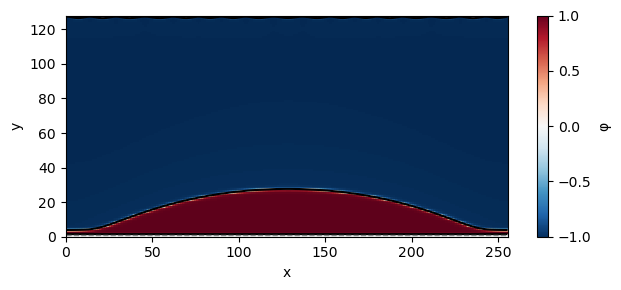

In [15]:
# --- EXPERIMENT HERE ---
# Change the value of G_ads to see its effect on wettability. Here are some example values:
G_ads_to_test = -3  # (Hydrophilic / Wetting, angle < 90°)
# G_ads_to_test =  0  # (Neutral, angle ≈ 90°)
# G_ads_to_test =  1  # (Hydrophobic / Non-wetting, angle > 90°)

contact_angle_lbm = contact_angle(G_ads_value=G_ads_to_test, max_steps=5000)

phi = contact_angle_lbm.compute_phase_field()  # shape (nx, ny), indexed [x, y]
nx, ny = contact_angle_lbm.nx, contact_angle_lbm.ny

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(phi.T, origin='lower', extent=[0, nx, 0, ny],
                cmap='RdBu_r', vmin=-1.0, vmax=1.0, interpolation='nearest', aspect='equal')
# Interface: phi = 0 contour
cs = ax.contour(phi.T, levels=[0.0], colors='k', linewidths=1.5, origin='lower', extent=[0, nx, 0, ny])
# Wall overlay (y=0 line)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1.0)  # first fluid row above wall
# Solid mask overlay (light gray)
ax.imshow(contact_angle_lbm.solid_mask.T, origin='lower', extent=[0, nx, 0, ny],
            cmap='gray', alpha=0.15, vmin=0, vmax=1.0)

ax.set_xlabel("x")
ax.set_ylabel("y")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("φ")
plt.tight_layout()